## Machine Learning Project 

### BTech Data Science and Engineering 


### Prayas Gupta 230968236

1. Objective: Develop a machine learning model to classify news articles as real or fake based on textual content.

2. Dataset: Used a labeled dataset with article titles, content, and labels indicating whether the news is fake or real.

3. Preprocessing: Removed missing values and combined the title and body of each article to improve context.

4. Vectorization: Applied TF-IDF (Term Frequency-Inverse Document Frequency) to convert textual data into numerical feature vectors.

5. Train-Test Split: Divided the data into training (75%) and testing (25%) sets for model evaluation.

6. Model 1 - Logistic Regression: Provided strong performance in terms of accuracy and interpretability.

7. Model 2 - Passive Aggressive Classifier: Offered efficient training on large-scale data with good results.

8. Model 3 - XGBoost: Delivered the most accurate results but required more computational resources.

9. Evaluation: Assessed model performance using accuracy scores and confusion matrices to determine classification effectiveness.

10. Application: The final model can be used to predict the authenticity of new articles and integrated into fact-checking platforms.

In [11]:
import pandas as pd 

In [13]:
df = pd.read_csv("test.csv")

In [15]:
df

,Unnamed: 0,title,text,subject,date,fake
0,12,Bad News For Trump — Mitch McConnell Says No ...,Republicans have had seven years to come up wi...,News,"December 21, 2017",1
1,17,Mueller Spokesman Just F-cked Up Donald Trump...,Trump supporters and the so-called president s...,News,"December 17, 2017",1
2,18,SNL Hilariously Mocks Accused Child Molester ...,"Right now, the whole world is looking at the s...",News,"December 17, 2017",1
3,21,KY GOP State Rep. Commits Suicide Over Allega...,"In this #METOO moment, many powerful men are b...",News,"December 13, 2017",1
4,24,White House: It Wasn’t Sexist For Trump To Sl...,A backlash ensued after Donald Trump launched ...,News,"December 12, 2017",1
...,...,...,...,...,...,...
10838,21396,Pro-Houthi fighters call powerful Yemen ally '...,DUBAI (Reuters) - Fighters loyal to the armed ...,worldnews,"August 23, 2017",0
10839,21397,Germany's Schulz says he would demand U.S. wit...,BERLIN (Reuters) - The leader of Germany s Soc...,worldnews,"August 23, 2017",0
10840,21399,Saudi police release teenager detained for dan...,DUBAI (Reuters) - A 14-year-old boy who was de...,worldnews,"August 22, 2017",0
10841,21409,"U.S., North Korea clash at U.N. arms forum on ...",GENEVA (Reuters) - North Korea and the United ...,worldnews,"August 22, 2017",0


In [17]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10843 entries, 0 to 10842
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  10843 non-null  int64 
 1   title       10843 non-null  object
 2   text        10843 non-null  object
 3   subject     10843 non-null  object
 4   date        10843 non-null  object
 5   fake        10843 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 508.4+ KB
None


In [19]:
df.head()

,Unnamed: 0,title,text,subject,date,fake
0,12,Bad News For Trump — Mitch McConnell Says No ...,Republicans have had seven years to come up wi...,News,"December 21, 2017",1
1,17,Mueller Spokesman Just F-cked Up Donald Trump...,Trump supporters and the so-called president s...,News,"December 17, 2017",1
2,18,SNL Hilariously Mocks Accused Child Molester ...,"Right now, the whole world is looking at the s...",News,"December 17, 2017",1
3,21,KY GOP State Rep. Commits Suicide Over Allega...,"In this #METOO moment, many powerful men are b...",News,"December 13, 2017",1
4,24,White House: It Wasn’t Sexist For Trump To Sl...,A backlash ensued after Donald Trump launched ...,News,"December 12, 2017",1


In [86]:
# Preprocessing the Data 

In [23]:
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [24]:
#removing unneccesary columns(like unnamed ones)
df = df.drop(columns=["Unnamed:0"],errors = 'ignore')
df

,Unnamed: 0,title,text,subject,date,fake
0,12,Bad News For Trump — Mitch McConnell Says No ...,Republicans have had seven years to come up wi...,News,"December 21, 2017",1
1,17,Mueller Spokesman Just F-cked Up Donald Trump...,Trump supporters and the so-called president s...,News,"December 17, 2017",1
2,18,SNL Hilariously Mocks Accused Child Molester ...,"Right now, the whole world is looking at the s...",News,"December 17, 2017",1
3,21,KY GOP State Rep. Commits Suicide Over Allega...,"In this #METOO moment, many powerful men are b...",News,"December 13, 2017",1
4,24,White House: It Wasn’t Sexist For Trump To Sl...,A backlash ensued after Donald Trump launched ...,News,"December 12, 2017",1
...,...,...,...,...,...,...
10838,21396,Pro-Houthi fighters call powerful Yemen ally '...,DUBAI (Reuters) - Fighters loyal to the armed ...,worldnews,"August 23, 2017",0
10839,21397,Germany's Schulz says he would demand U.S. wit...,BERLIN (Reuters) - The leader of Germany s Soc...,worldnews,"August 23, 2017",0
10840,21399,Saudi police release teenager detained for dan...,DUBAI (Reuters) - A 14-year-old boy who was de...,worldnews,"August 22, 2017",0
10841,21409,"U.S., North Korea clash at U.N. arms forum on ...",GENEVA (Reuters) - North Korea and the United ...,worldnews,"August 22, 2017",0


In [89]:
#combining title and text 
df["content"] = df["title"].fillna('') + " " + df["text"].fillna('')

In [27]:
#cleaning the text

In [31]:
def clean_text(text):
    text = re.sub(r'\W+', ' ', text)  # removing punctuation
    text = re.sub(r'\d+', '', text)   # removing numbers
    return text.lower()

df["cleaned_content"] = df["content"].apply(clean_text)


In [32]:
#training the dataset 
X_train, X_test, y_train, y_test = train_test_split(
    df["cleaned_content"], df["fake"], test_size=0.2, random_state=42
)

In [35]:
# TF - IDF VECTORIZATION

In [37]:
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [38]:
#STEP BY STEP  DISPLAYING OF PREPROCESSING

In [41]:
print(df[['title', 'text']].head(2))
print(df['content'].head(2))
print(df['cleaned_content'].head(2))
df[['content', 'cleaned_content']].head(3)


                                               title  \
0   Bad News For Trump — Mitch McConnell Says No ...   
1   Mueller Spokesman Just F-cked Up Donald Trump...   

                                                text  
0  Republicans have had seven years to come up wi...  
1  Trump supporters and the so-called president s...  
0     Bad News For Trump — Mitch McConnell Says No ...
1     Mueller Spokesman Just F-cked Up Donald Trump...
Name: content, dtype: object
0     bad news for trump mitch mcconnell says no to...
1     mueller spokesman just f cked up donald trump...
Name: cleaned_content, dtype: object


,content,cleaned_content
0,Bad News For Trump — Mitch McConnell Says No ...,bad news for trump mitch mcconnell says no to...
1,Mueller Spokesman Just F-cked Up Donald Trump...,mueller spokesman just f cked up donald trump...
2,SNL Hilariously Mocks Accused Child Molester ...,snl hilariously mocks accused child molester ...


In [43]:
# now training the multinomial naive bayes on vectorized data

In [45]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [47]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)


MultinomialNB()

In [49]:
#predicting the test set 
y_pred = model.predict(X_test_tfidf)

In [51]:
# checking the accuracy and other metrics

In [53]:
# Accuracy :
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Classification Report :
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["REAL", "FAKE"]))

# Confusion Matrix :
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9378

Classification Report:
              precision    recall  f1-score   support

        REAL       0.93      0.94      0.94      1057
        FAKE       0.94      0.94      0.94      1112

    accuracy                           0.94      2169
   macro avg       0.94      0.94      0.94      2169
weighted avg       0.94      0.94      0.94      2169


Confusion Matrix:
[[ 994   63]
 [  72 1040]]


In [55]:
#using logistic regression 

In [57]:
from sklearn.linear_model import LogisticRegression

In [59]:
#training the model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [61]:
#predicting the model 
y_pred_log = log_model.predict(X_test_tfidf)

In [63]:
#accuracy
accuracy_log = accuracy_score(y_test, y_pred_log)
print(f"Logistic Regression Accuracy: {accuracy_log:.4f}")

Logistic Regression Accuracy: 0.9728


In [74]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [73]:
# using xgboost

In [67]:
import xgboost as xgb
from sklearn.metrics import accuracy_score

In [68]:
xgb_model = xgb.XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42)
#training the model 
xgb_model.fit(X_train_tfidf, y_train)
#predicting the model
y_pred_xgb = xgb_model.predict(X_test_tfidf)

In [69]:
#accuracy 
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {accuracy_xgb:.4f}")

XGBoost Accuracy: 0.9945


In [91]:
#visualization 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

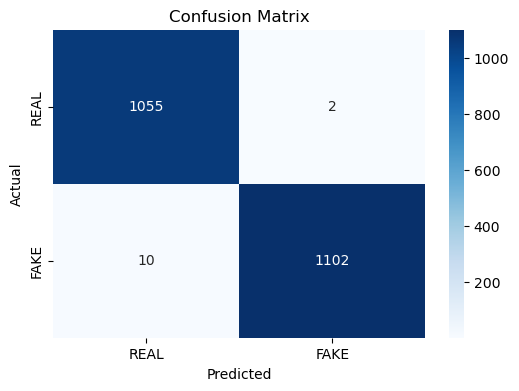

In [93]:
# Generating the Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)  # Change model if needed
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["REAL", "FAKE"], yticklabels=["REAL", "FAKE"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

C:\Users\praya\AppData\Local\Temp\ipykernel_38852\2762272054.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette="coolwarm")


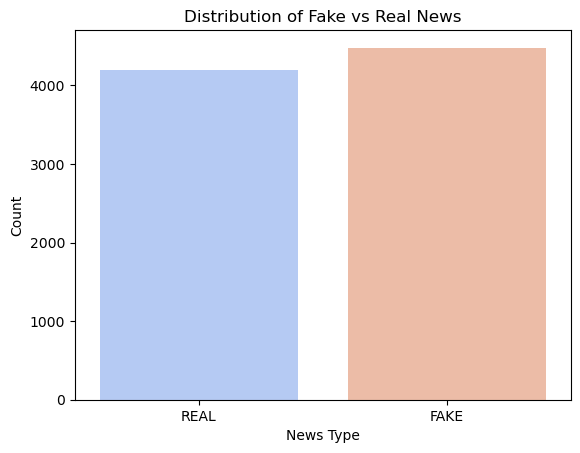

In [95]:
# it helps to check balance 
sns.countplot(x=y_train, palette="coolwarm")
plt.title("Distribution of Fake vs Real News")
plt.xlabel("News Type")
plt.ylabel("Count")
plt.xticks(ticks=[0,1], labels=["REAL", "FAKE"])
plt.show()

In [124]:
import pickle

# Save model & vectorizer
with open("fake_news_model.pkl", "wb") as model_file:
    pickle.dump(model, model_file)

with open("tfidf_vectorizer.pkl", "wb") as vectorizer_file:
    pickle.dump(vectorizer, vectorizer_file)

In [132]:
import streamlit as st
import pickle

# Load the trained model and vectorizer
with open("fake_news_model.pkl", "rb") as model_file:
    model = pickle.load(model_file)

with open("tfidf_vectorizer.pkl", "rb") as vectorizer_file:
    vectorizer = pickle.load(vectorizer_file)

# Streamlit UI
st.title("📰 Fake News Detector")
st.subheader("Enter a news article to check its authenticity")

# User Input
news_text = st.text_area("Paste the news content here:")

if st.button("Predict"):
    if not news_text.strip():
        st.warning("⚠️ Please enter some text to analyze.")
    else:
        # Transform text using the vectorizer
        transformed_text = vectorizer.transform([news_text])
        # Prediction
        prediction = model.predict(transformed_text)[0]

        # Display result
        if prediction == 1:
            st.error("❌ This news is likely **FAKE**.")
        else:
            st.success("✅ This news seems to be **REAL**.")

2025-04-04 19:51:38.807 
  command:

    streamlit run C:\Users\praya\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-04-04 19:51:38.807 Session state does not function when running a script without `streamlit run`


In [138]:
import os
print (os.getcwd())

C:\Users\praya
